# Video estimate for Fortune 500 CEOs - USA

## Set up CEOs list

In [3]:
import json
import csv

with open("data/ceos_usa_2023.csv") as f:
    companies = list(csv.DictReader(f))

ceos_usa = [
    {
        "CEO": c["CEO"],
        "Company": c["Company"],
        "year": 2023,
        "general_videos_collected": False,
        "dei_videos_collected": False
    }
    for c in companies
]

with open("data/ceos_usa_2023.json", "w") as f:
    json.dump(ceos_usa, f, indent=2)

print(f"Wrote {len(ceos_usa)} companies")

Wrote 500 companies


In [5]:
import json
import re

with open("data/ceos_usa_2023.json") as f:
    ceos_usa = json.load(f)

def strip_middle_initial(name):
    alt = re.sub(r"\s+[A-Z]\.?\s+", " ", name)
    return alt.strip()

for c in ceos_usa:
    alt = strip_middle_initial(c["CEO"])
    c["CEO_alt"] = alt if alt != c["CEO"] else None

with open("data/ceos_usa_2023.json", "w") as f:
    json.dump(ceos_usa, f, indent=2)

In [6]:
import json

with open("data/ceos_usa_2023.json") as f:
    ceos_usa = json.load(f)

ceos_usa = [c for c in ceos_usa if c.get("CEO")]

with open("data/ceos_usa_2023.json", "w") as f:
    json.dump(ceos_usa, f, indent=2)

print(f"Remaining: {len(ceos_usa)}")

Remaining: 476


## Get videos per CEO

In [ ]:
import os
import json
from dotenv import load_dotenv
from googleapiclient.discovery import build

load_dotenv()

youtube = build(
    "youtube",
    "v3",
    developerKey=os.getenv("YOUTUBE_API_KEY_2")
)

CEOS_PATH = "data/ceos_usa_2023.json"
OUTPUT_DIR = "output/estimation/2023_USA/general"

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(CEOS_PATH) as f:
    ceo_list = json.load(f)

eligible_ceos = [c["CEO"] for c in ceo_list if not c.get("general_videos_collected")]

if len(eligible_ceos) == 0:
    print("No new CEOs left to collect.")
else:
    for ceo in eligible_ceos:
        search_response = youtube.search().list(
            part="snippet",
            q=f"{ceo} interview",
            type="video",
            publishedAfter="2023-01-01T00:00:00Z",
            publishedBefore="2024-01-01T00:00:00Z",
            maxResults=50
        ).execute()

        video_ids = [
            item["id"]["videoId"]
            for item in search_response["items"]
        ]

        details_response = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=",".join(video_ids)
        ).execute() if video_ids else {"items": []}

        output = {
            "ceo": ceo,
            "search_results": search_response,
            "video_details": details_response
        }

        with open(f"{OUTPUT_DIR}/{ceo}.json", "w") as f:
            json.dump(output, f, indent=2)

        # Update ceos_usa_2023.json immediately after success
        with open(CEOS_PATH) as f:
            ceo_list = json.load(f)

        for c in ceo_list:
            if c["CEO"] == ceo:
                c["general_videos_collected"] = True
                break

        with open(CEOS_PATH, "w") as f:
            json.dump(ceo_list, f, indent=2)

        print(f"Completed: {ceo}")

In [ ]:
import os
import json

CEOS_PATH = "data/ceos_usa_2023.json"
GENERAL_DIR = "output/estimation/2023_USA/general"
POSTPROCESSED_DIR = f"{GENERAL_DIR}/preprocessed"

os.makedirs(POSTPROCESSED_DIR, exist_ok=True)

with open(CEOS_PATH) as f:
    ceo_list = json.load(f)

alt_lookup = {c["CEO"]: c.get("CEO_alt") for c in ceo_list}

def name_in_title(name, title):
    if not name or not title:
        return False
    return name.lower() in title.lower()

for file in os.listdir(GENERAL_DIR):
    if not file.endswith(".json"):
        continue

    filepath = os.path.join(GENERAL_DIR, file)
    if not os.path.isfile(filepath):
        continue

    with open(filepath) as f:
        data = json.load(f)

    ceo = data["ceo"]
    ceo_alt = alt_lookup.get(ceo)

    original_items = data.get("video_details", {}).get("items", [])
    filtered_items = [
        video for video in original_items
        if name_in_title(ceo, video.get("snippet", {}).get("title", ""))
        or name_in_title(ceo_alt, video.get("snippet", {}).get("title", ""))
    ]

    kept_video_ids = {video["id"] for video in filtered_items}

    original_search_items = data.get("search_results", {}).get("items", [])
    filtered_search_items = [
        item for item in original_search_items
        if item.get("id", {}).get("videoId") in kept_video_ids
    ]

    new_data = dict(data)
    new_data["search_results"] = dict(data.get("search_results", {}))
    new_data["search_results"]["items"] = filtered_search_items
    new_data["video_details"] = dict(data.get("video_details", {}))
    new_data["video_details"]["items"] = filtered_items

    with open(os.path.join(POSTPROCESSED_DIR, file), "w") as f:
        json.dump(new_data, f, indent=2)

    print(f"{ceo}: kept {len(filtered_items)}/{len(original_items)} videos")

### Statistics - general interviews

In [12]:
import os
import json

GENERAL_DIR = "output/estimation/2023_USA/general"
PREPROCESSED_DIR = f"{GENERAL_DIR}/preprocessed"

def summarize(directory):
    n_ceos = 0
    total_videos = 0

    for file in os.listdir(directory):
        filepath = os.path.join(directory, file)
        if not file.endswith(".json") or not os.path.isfile(filepath):
            continue

        with open(filepath) as f:
            data = json.load(f)

        n_ceos += 1
        total_videos += len(data.get("video_details", {}).get("items", []))

    avg_videos = total_videos / n_ceos if n_ceos else 0
    return n_ceos, total_videos, avg_videos

# Unprocessed
n_ceos_raw, total_raw, avg_raw = summarize(GENERAL_DIR)
print("UNPROCESSED")
print(f"  Total CEOs: {n_ceos_raw}")
print(f"  Total videos collected: {total_raw}")
print(f"  Average videos per CEO: {avg_raw:.2f}")

# Preprocessed
n_ceos_clean, total_clean, avg_clean = summarize(PREPROCESSED_DIR)
print("\nPREPROCESSED")
print(f"  CEOs with at least one video: {n_ceos_clean}")
print(f"  Total videos collected: {total_clean}")
print(f"  Average videos per CEO: {avg_clean:.2f}")

UNPROCESSED
  Total CEOs: 222
  Total videos collected: 8130
  Average videos per CEO: 36.62

PREPROCESSED
  CEOs with at least one video: 222
  Total videos collected: 1082
  Average videos per CEO: 4.87


In [31]:
import os
import json
import random

PREPROCESSED_DIR = "output/estimation/2023_USA/general/preprocessed"

all_videos = []

for file in os.listdir(PREPROCESSED_DIR):
    filepath = os.path.join(PREPROCESSED_DIR, file)
    if not file.endswith(".json") or not os.path.isfile(filepath):
        continue

    with open(filepath) as f:
        data = json.load(f)

    for item in data.get("search_results", {}).get("items", []):
        title = item["snippet"]["title"]
        video_id = item["id"]["videoId"]
        all_videos.append((title, video_id))

sample = random.sample(all_videos, min(5, len(all_videos)))

for title, video_id in sample:
    print(title)
    print(f"https://www.youtube.com/watch?v={video_id}")
    print()

I am getting SUED by WBD &amp; David Zaslav!?!?
https://www.youtube.com/watch?v=W3zufMqnFuI

Lorenzo Simonelli of Baker Hughes stresses importance of using energy mix
https://www.youtube.com/watch?v=iSRwx5EyRZk

Magazine TED - Interview with David Solomon
https://www.youtube.com/watch?v=uLjYeN3eG5k

The year has started off better than anyone expected, Citi&#39;s says Jane Fraser
https://www.youtube.com/watch?v=O1WXTnEJHVE

&quot;India Now Has Very High Growth Trajectory&quot;: Goldman Sachs CEO | David Solomon | English News
https://www.youtube.com/watch?v=7BtlM0yoNI4



C:\Users\sonia.nicoletti\AppData\Local\Temp\ipykernel_8280\3198941455.py:40: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(video_counts, vert=True, patch_artist=True,


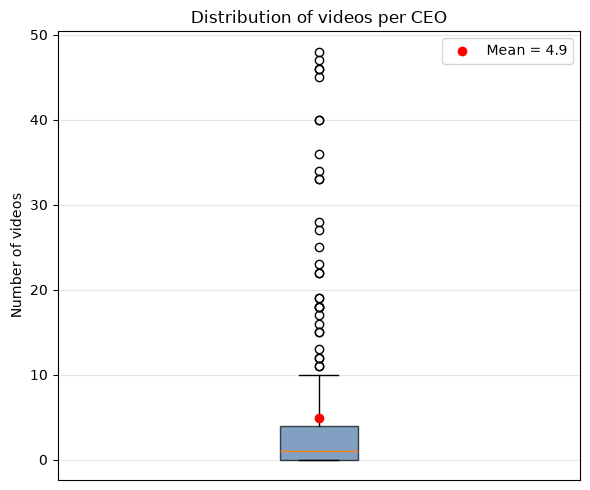

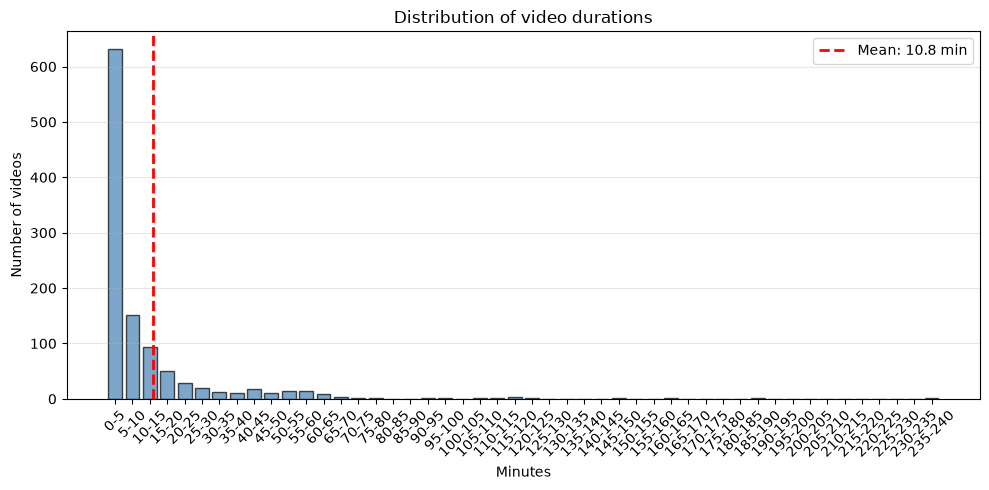

In [18]:
import os
import json
import re
import matplotlib.pyplot as plt
import numpy as np

PREPROCESSED_DIR = "output/estimation/2023_USA/general/preprocessed"

def duration_to_seconds(duration):
    hours = re.search(r"(\d+)H", duration)
    minutes = re.search(r"(\d+)M", duration)
    seconds = re.search(r"(\d+)S", duration)

    return (
        (int(hours.group(1)) * 3600 if hours else 0) +
        (int(minutes.group(1)) * 60 if minutes else 0) +
        (int(seconds.group(1)) if seconds else 0)
    )

video_counts = []
all_durations = []

for file in os.listdir(PREPROCESSED_DIR):
    filepath = os.path.join(PREPROCESSED_DIR, file)
    if not file.endswith(".json") or not os.path.isfile(filepath):
        continue

    with open(filepath) as f:
        data = json.load(f)

    items = data.get("video_details", {}).get("items", [])
    video_counts.append(len(items))

    for video in items:
        duration_min = duration_to_seconds(video["contentDetails"]["duration"]) / 60
        all_durations.append(duration_min)

# Plot 1: box plot of number of videos per CEO
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(video_counts, vert=True, patch_artist=True,
           boxprops=dict(facecolor="#4c78a8", alpha=0.7))
ax.scatter([1], [np.mean(video_counts)], color="red", zorder=3, label=f"Mean = {np.mean(video_counts):.1f}")
ax.set_ylabel("Number of videos")
ax.set_title("Distribution of videos per CEO")
ax.set_xticks([])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: bar plot of video durations in 5-minute bins
max_duration = max(all_durations) if all_durations else 0
bins = np.arange(0, max_duration + 5, 5)
counts, bin_edges = np.histogram(all_durations, bins=bins)
bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(len(bin_edges) - 1)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bin_labels, counts, color="steelblue", edgecolor="black", alpha=0.7)

mean_duration = np.mean(all_durations)
ax.axvline(mean_duration / 5, color="red", linestyle="--", linewidth=2,
           label=f"Mean: {mean_duration:.1f} min")

ax.set_xlabel("Minutes")
ax.set_ylabel("Number of videos")
ax.set_title("Distribution of video durations")
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [29]:
import os
import json
import random

PREPROCESSED_DIR = "output/estimation/2023_USA/general/preprocessed"

DEI_KEYWORDS = [
    "diversity",
    "diverse",
    "inclusion",
    "inclusivity",
    "inclusive",
    "equity",
    "equal",
    "equality",
    "DEI",
    "belonging",
    "racial equity",
    "racial justice",
    "anti-racism",
    "underrepresented minorities",
    "people of color",
    "Black",
    "Hispanic",
    "Asian",
    "gender",
    "women",
    "woman",
    "female",
    "gender pay gap",
    "empowerment",
    "LGBTQ",
    "LGBTQ+",
    "LGBTQIA",
    "trans",
    "transgender",
    "pride",
    "sexual orientation",
    "accessibility",
    "disabled",
    "neurodiversity",
    "neurodiverse",
    "ageism",
    "employee resource groups",
    "ERG",
    "ERGs",
    "affinity groups",
    "bias",
    "microaggressions",
    "psychological safety",
    "ESG",
    "responsibility",
    "CSR",
    "stakeholder",
    "stakeholders",
    "affirmative action",
    "representation"
]

def title_has_dei_term(title):
    if not title:
        return False
    title_lower = title.lower()

    for keyword in DEI_KEYWORDS:
        keyword_lower = keyword.lower()

        if " " in keyword_lower:
            # Multi-word phrase: plain substring check is fine,
            # since phrases are unlikely to appear as accidental substrings
            if keyword_lower in title_lower:
                return True
        else:
            # Single word: require a word boundary on both sides,
            # so "ERG" doesn't match inside "energy" or "Zuckerberg"
            pattern = r"\b" + re.escape(keyword_lower) + r"\b"
            if re.search(pattern, title_lower):
                return True
    return False

dei_videos_by_ceo = {}  # temporary, in-memory only

for file in os.listdir(PREPROCESSED_DIR):
    filepath = os.path.join(PREPROCESSED_DIR, file)
    if not file.endswith(".json") or not os.path.isfile(filepath):
        continue

    with open(filepath) as f:
        data = json.load(f)

    ceo = data["ceo"]
    items = data.get("video_details", {}).get("items", [])

    matched_videos = [
        video for video in items
        if title_has_dei_term(video.get("snippet", {}).get("title", ""))
    ]

    if matched_videos:
        dei_videos_by_ceo[ceo] = matched_videos

n_ceos_with_dei = len(dei_videos_by_ceo)
total_dei_videos = sum(len(v) for v in dei_videos_by_ceo.values())
avg_dei_videos = total_dei_videos / n_ceos_with_dei if n_ceos_with_dei else 0

print(f"CEOs with at least one DEI-related video (in title): {n_ceos_with_dei}")
print(f"Total DEI-related videos: {total_dei_videos}")
print(f"Average DEI-related videos per CEO: {avg_dei_videos:.2f} \n")

flat_dei_videos = [
    (ceo, video["snippet"]["title"], video["id"])
    for ceo, videos in dei_videos_by_ceo.items()
    for video in videos
]

sample = random.sample(flat_dei_videos, min(5, len(flat_dei_videos)))

for ceo, title, video_id in sample:
    print(f"CEO: {ceo}")
    print(title)
    print(f"https://www.youtube.com/watch?v={video_id}")
    print()

CEOs with at least one DEI-related video (in title): 16
Total DEI-related videos: 18
Average DEI-related videos per CEO: 1.12 

CEO: Jack Dorsey
Isaiah Jackson recounts when Jack Dorsey retweeted #Bitcoin and Black America | #shorts
https://www.youtube.com/watch?v=u5zkYziEmA0

CEO: Mary T. Barra
General Motors CEO Advice for Women | Mary Barra
https://www.youtube.com/watch?v=12_a8VYwvFg

CEO: David M. Zaslav
CNN corporate head David Zaslav takes ‘full responsibility’ for disastrous Chris Licht tenure
https://www.youtube.com/watch?v=z80owmrz5To

CEO: Karen S. Lynch
Karen Lynch , The Journey to Becoming a Powerful Woman | president and CEO of CVS Health
https://www.youtube.com/watch?v=tDSxKuRe5S4

CEO: Mary T. Barra
You Should Watch This, Mary Barra Best inspirational woman in automotive industry
https://www.youtube.com/watch?v=1jT30b9NQzU

